In [4]:
import numpy as np
import logging
logging.basicConfig(level=logging.INFO)
import matplotlib.pyplot as plt
import importlib
import sys 
sys.path.append('..')

import utils
from utils.model import Spin1Chain
from utils.model import ModelParams

from tenpy.models.model import CouplingMPOModel
from tenpy.networks.site import SpinSite
from tenpy.algorithms import dmrg
from tenpy.networks.mps import MPS

from dataclasses import asdict

In [ ]:
importlib.reload(utils.model)

<module 'utils.model' from '/scratch/ashankar/Spin1LongRangeOrder.jl/python/notebooks/../utils/model.py'>

In [13]:
def_params = asdict(ModelParams())
model = Spin1Chain(def_params)
print(def_params)


INFO:tenpy.tools.params:Spin1Chain: reading 'conserve'=None
INFO:tenpy.tools.params:Spin1Chain: reading 'S'=1
INFO:tenpy.tools.params:Spin1Chain: reading 'bc_MPS'='infinite'
INFO:tenpy.tools.params:Spin1Chain: reading 'L'=2
INFO:tenpy.tools.params:Spin1Chain: reading 'J'=-1.0
INFO:tenpy.tools.params:Spin1Chain: reading 'g1'=0.2
INFO:tenpy.tools.params:Spin1Chain: reading 'g2'=0.0


{'L': 2, 'S': 1, 'J': -1.0, 'g1': 0.2, 'g2': 0.0, 'bc_MPS': 'infinite', 'conserve': None, 'explicit_plus_hc': False, 'lattice': 'Chain', 'bc_x': 'periodic', 'order': 'default', 'helical_lattice': None, 'irregular_remove': None, 'sort_mpo_legs': False}


In [ ]:
def run(gs):
    print('running for gs = ', gs)
    L = 2
    chi = 100 #100 
    dmrg_params = {
        'trunc_params': {'chi_max': chi, 'svd_min': 1.0e-10, 'trunc_cut': None},
        'update_env': 5,
        'start_env': 5,
        'max_E_err': 0.0001,
        'max_S_err': 0.0001,
        'max_sweeps': 100,  # NOTE: this is not enough to fully converge at the critical point!
        'mixer': False,
    }

    model_params = asdict(ModelParams())
    model_params['g2'] = gs[0]
    model = Spin1Chain(model_params)
    psi = MPS.from_product_state(
        model.lat.mps_sites(), (['up', 'up'] * L)[:L], model.lat.bc_MPS, unit_cell_width=model.lat.mps_unit_cell_width
    )

    engine = dmrg.TwoSiteDMRGEngine(psi, model, dmrg_params)
    np.set_printoptions(linewidth=120)

    corr_length = []
    fidelity = []
    Sz = []
    E = []
    S = []
    SpSm = []
    old_psi = None
    for g in gs:
        print('-' * 80)
        print('g =', g)
        print('-' * 80)
        model_params['g2'] = g
        model = Spin1Chain(model_params)
        engine.init_env(model=model)  # (re)initialize DMRG environment with new model
        # this uses the result from the previous DMRG as first initial guess
        E0, psi = engine.run()
        E.append(E0)
        # psi is modified by engine.run() and now represents the ground state for the current `g`.
        S.append(psi.entanglement_entropy()[0])
        corr_length.append(psi.correlation_length(tol_ev0=1.0e-3))
        print('corr. length', corr_length[-1])
        Sz.append(psi.expectation_value('Sz', [0])[0])
        print('<Sz>', Sz[-1])
        SpSm.append(psi.correlation_function('Sp', 'Sm', [0], 20)[0, :])
        print('<Sp_0 Sm_i>', SpSm[-1])
        if old_psi is not None:
            fidelity.append(np.abs(old_psi.overlap(psi, understood_infinite=True)))
            print('fidelity', fidelity[-1])
        old_psi = psi.copy()
        dmrg_params['start_env'] = 0  # (some of) the parameters are read out again
    results = {
        'model_params': model_params,
        'dmrg_params': dmrg_params,
        'gs': gs,
        'corr_length': np.array(corr_length),
        'fidelity': np.array(fidelity),
        'Sz': np.array(Sz),
        'E': np.array(E),
        'S': np.array(S),
        'SpSm': np.array(SpSm),
        'eval_transfermatrix': np.exp(-1.0 / np.array(corr_length)),
    }
    return results

def plot(results, filename):
    fig, axes = plt.subplots(2, 3, gridspec_kw=dict(wspace=0.3, hspace=0.3), figsize=(15, 10))
    gs = np.array(results['gs'])
    for ax, key in zip(axes.flatten(), ['E', 'S', 'SpSm', 'Sz', 'eval_transfermatrix', 'fidelity']):
        if key == 'fidelity':
            ax.plot(0.5 * (gs[1:] + gs[:-1]), np.abs(results[key]), 'ro-')
        elif key == 'SpSm':
            cm = plt.cm.get_cmap('viridis')
            SpSm = results[key]
            max_j = SpSm.shape[1]
            for j in range(1, max_j):
                label = f'j= {j:d}' if j in [1, max_j - 1] else None
                ax.plot(gs, SpSm[:, j], label=label, color=cm(j / max_j))
            ax.legend()
        else:
            ax.plot(gs, results[key], 'ro-')
        ax.set_xlabel('$g/J$')
        ax.set_ylabel(key)
        ax.set_xlim(min(gs), max(gs))
    plt.savefig(filename)
    print('saved to ' + filename)

INFO:tenpy.tools.params:Spin1Chain: reading 'conserve'=None
INFO:tenpy.tools.params:Spin1Chain: reading 'S'=1
INFO:tenpy.tools.params:Spin1Chain: reading 'bc_MPS'='infinite'
INFO:tenpy.tools.params:Spin1Chain: reading 'L'=2
INFO:tenpy.tools.params:Spin1Chain: reading 'J'=-1.0
INFO:tenpy.tools.params:Spin1Chain: reading 'g1'=0.2
INFO:tenpy.tools.params:Spin1Chain: reading 'g2'=np.float64(0.2)
INFO:tenpy.tools.params:TwoSiteDMRGEngine: subconfig 'trunc_params'=Config(<3 options>, 'trunc_params')
INFO:tenpy.tools.params:TwoSiteDMRGEngine: reading 'start_env'=5
INFO:tenpy.algorithms.mps_common:start environment_sweep
INFO:tenpy.tools.params:trunc_params: reading 'chi_max'=100
INFO:tenpy.tools.params:trunc_params: reading 'svd_min'=1e-10
INFO:tenpy.tools.params:trunc_params: reading 'trunc_cut'=None


running for gs =  [0.2 0.3]


INFO:tenpy.tools.params:Spin1Chain: reading 'explicit_plus_hc'=False
INFO:tenpy.tools.params:Spin1Chain: reading 'lattice'='Chain'
INFO:tenpy.tools.params:Spin1Chain: reading 'conserve'=None
INFO:tenpy.tools.params:Spin1Chain: reading 'S'=1
INFO:tenpy.tools.params:Spin1Chain: reading 'bc_MPS'='infinite'
INFO:tenpy.tools.params:Spin1Chain: reading 'bc_x'='periodic'
INFO:tenpy.tools.params:Spin1Chain: reading 'order'='default'
INFO:tenpy.tools.params:Spin1Chain: reading 'L'=2
INFO:tenpy.tools.params:Spin1Chain: reading 'helical_lattice'=None
INFO:tenpy.tools.params:Spin1Chain: reading 'irregular_remove'=None
INFO:tenpy.tools.params:Spin1Chain: reading 'J'=-1.0
INFO:tenpy.tools.params:Spin1Chain: reading 'g1'=0.2
INFO:tenpy.tools.params:Spin1Chain: reading 'g2'=np.float64(0.2)
INFO:tenpy.tools.params:Spin1Chain: reading 'sort_mpo_legs'=False
INFO:tenpy.algorithms.mps_common:start environment_sweep
INFO:tenpy.tools.params:TwoSiteDMRGEngine: reading 'mixer'=False
INFO:tenpy.tools.params:Two

--------------------------------------------------------------------------------
g = 0.2
--------------------------------------------------------------------------------


INFO:tenpy.tools.params:TwoSiteDMRGEngine: reading 'update_env'=5
INFO:tenpy.algorithms.mps_common:start environment_sweep
INFO:tenpy.algorithms.dmrg:checkpoint after sweep 10
energy=-0.8688544076628005, max S=1.6470385985159057, age=200, norm_err=6.9e-04
Current memory usage 328.7MB, wall time: 117.8s
Delta E = nan, Delta S = 1.6463e-01 (per sweep)
max trunc_err = 1.5066e-08, max E_trunc = 7.5886e-08
chi: [100, 100]
INFO:tenpy.algorithms.dmrg:Running sweep with optimization
INFO:tenpy.algorithms.mps_common:start environment_sweep
INFO:tenpy.algorithms.dmrg:checkpoint after sweep 20
energy=-0.8688591448123795, max S=1.7551765535147246, age=320, norm_err=3.5e-04
Current memory usage 329.5MB, wall time: 80.0s
Delta E = -4.7371e-07, Delta S = 1.0850e-02 (per sweep)
max trunc_err = 8.9459e-08, max E_trunc = 4.4685e-07
chi: [100, 100]
INFO:tenpy.tools.params:TwoSiteDMRGEngine: reading 'max_E_err'=0.0001
INFO:tenpy.tools.params:TwoSiteDMRGEngine: reading 'max_S_err'=0.0001
INFO:tenpy.algorit

...

<Sp_0 Sm_i> [1.5787378  1.05085032 1.01656837 0.98993998 0.96858229 0.9509963  0.93617742 0.92344628 0.91233758 0.90251613
 0.89374022 0.88582049 0.87861754 0.87201409 0.8659246  0.86027218 0.85500226 0.85006237 0.84541663 0.84102807]
--------------------------------------------------------------------------------
g = 0.3
--------------------------------------------------------------------------------


INFO:tenpy.algorithms.mps_common:start environment_sweep
INFO:tenpy.algorithms.dmrg:checkpoint after sweep 10
energy=-0.8517518266692861, max S=1.7839168664606095, age=640, norm_err=1.2e-04
Current memory usage 331.7MB, wall time: 98.1s
Delta E = nan, Delta S = 1.0559e-03 (per sweep)
max trunc_err = 2.0009e-07, max E_trunc = 1.0320e-06
chi: [100, 100]
INFO:tenpy.algorithms.dmrg:Running sweep with optimization
INFO:tenpy.algorithms.mps_common:start environment_sweep
INFO:tenpy.algorithms.dmrg:checkpoint after sweep 20
energy=-0.8517521118858298, max S=1.7888691632869977, age=760, norm_err=4.2e-05
Current memory usage 331.7MB, wall time: 36.0s
Delta E = -2.8522e-08, Delta S = 4.9621e-04 (per sweep)
max trunc_err = 1.9245e-07, max E_trunc = 1.0307e-06
chi: [100, 100]
INFO:tenpy.algorithms.mps_common:TwoSiteDMRGEngine: Maximum number of sweeps reached
INFO:tenpy.algorithms.mps_common:start environment_sweep
INFO:tenpy.algorithms.mps_common:start environment_sweep
INFO:tenpy.algorithms.mps_

corr. length 815.9570548847804
<Sz> -1.9876317970973045e-07
<Sp_0 Sm_i> [1.58896968 1.04757728 1.00901321 0.9793965  0.95604379 0.93691512 0.92086444 0.90714344 0.89524291 0.88478331
 0.87548022 0.86711971 0.8595307  0.85258824 0.84618487 0.84024596 0.83470131 0.82950538 0.82461047 0.81998811]
fidelity 0.9997638034776479


/tmp/ipykernel_231444/2980383976.py:76: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cm = plt.cm.get_cmap('viridis')


saved to test.png


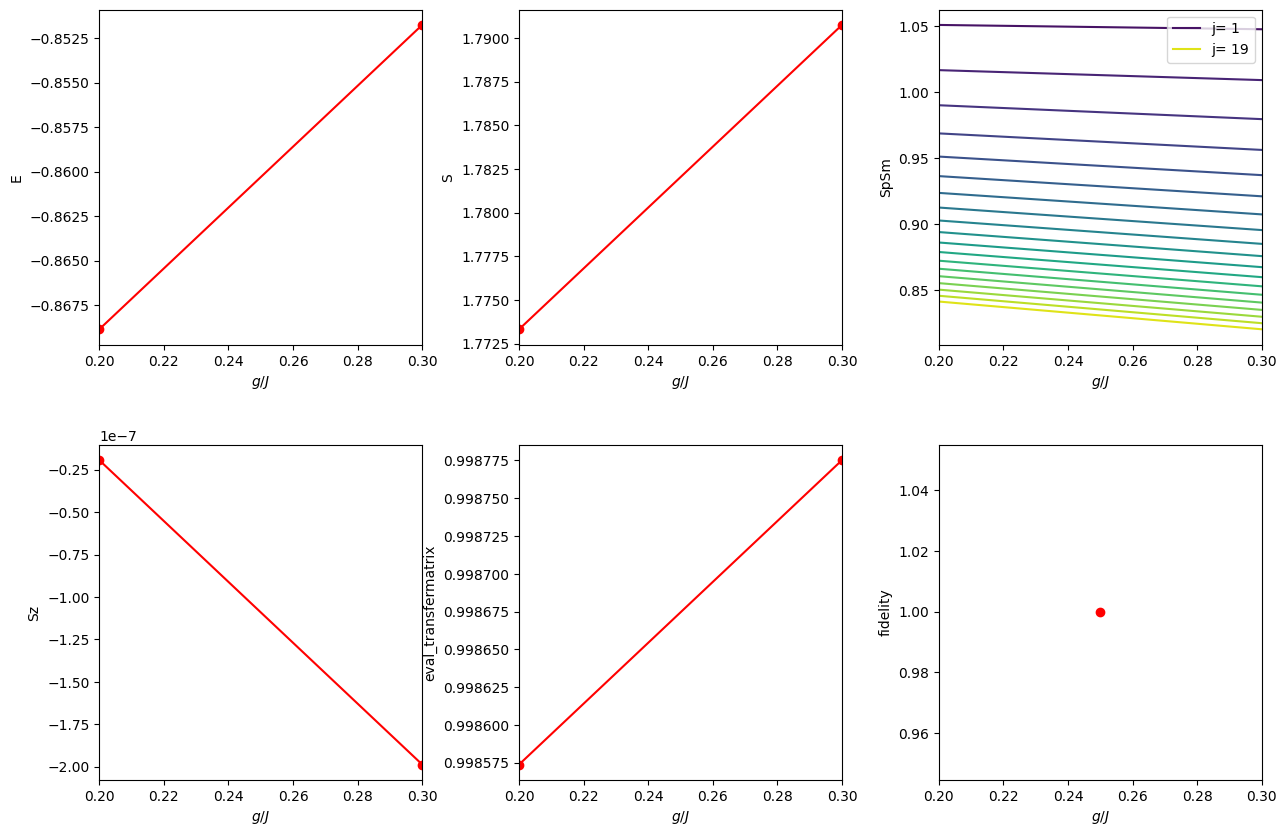

In [ ]:
filename = 'test.pkl'
import os.path
import pickle

if not os.path.exists(filename):
    # gs = sorted(set(np.linspace(0.5, 1.5, 11)).union(set(np.linspace(0.95, 1.05, 11))))[::-1]
    gs = np.linspace(0.2, 0.3, 3)
    results = run(gs)
    with open(filename, 'wb') as f:
        pickle.dump(results, f)
else:
    print('just load the data')
    with open(filename, 'rb') as f:
        results = pickle.load(f)
plot(results, filename[:-4] + '.png')

In [23]:
import re
import os, sys
sys.path.append('..')
from utils import io as io


def find_converged_psi(list_of_lists, target_vpm, tolerance=0.05):
    """
    Iterates through a list of lists of filenames, parses Vpm from filenames
    matching the pattern ...Vpm_####_chimax_####.h5, opens files whose Vpm is
    within `tolerance` of `target_vpm`, and returns the converged result with
    the closest Vpm value.

    Args:
        list_of_lists:  A list of lists, each containing filenames.
        io:             An object with an open() method returning (psi, metadata).
        target_vpm:     The target Vpm value to search near.
        tolerance:      Maximum allowed difference from target_vpm (default 0.05).

    Returns:
        (psi, metadata, vpm) for the converged file with Vpm closest to
        target_vpm, or None if no converged match is found within tolerance.
    """
    pattern = re.compile(r'Vpm_([\d.]+)_chimax_[\d.]+\.h5$')

    best_psi = None
    best_metadata = None
    best_vpm = None
    best_diff = float('inf')

    for file_list in list_of_lists:
        for filename in file_list:
            match = pattern.search(filename)
            if not match:
                continue

            vpm = float(match.group(1))
            diff = abs(vpm - target_vpm)

            if diff > tolerance or diff >= best_diff:
                continue

            psi, metadata = io.load_mps_with_metadata(filename)

            if metadata.get('converged') == True:
                best_psi = psi
                best_metadata = metadata
                best_vpm = vpm
                best_diff = diff

    return (best_psi, best_metadata, best_vpm) if best_psi is not None else None

ROOTDIR = "../../data/iDMRG/"
REQ_DATA_LIST = ['v2fwdchi300/t_1.00_U_0.10_Vpp_0.800_consNf0_25_chimax_300/',
                 #'v2fwdchi200/t_1.00_U_0.10_Vpp_0.800_consNf0_25_chimax_200/',
                 'v2fwd/t_1.00_U_0.10_Vpp_0.800_consNf0_25_chimax_100/',
                 ]
PATH_TO_REQ_DATA_LIST = [os.path.join(ROOTDIR, REQ_DATA) for REQ_DATA in REQ_DATA_LIST]
file_list = [[os.path.join(PATH_TO_REQ_DATA,f) for f in os.listdir(PATH_TO_REQ_DATA) ] for PATH_TO_REQ_DATA in PATH_TO_REQ_DATA_LIST]
# filenamelist = savefiletemplate = os.path.join(JOBDIR, f"Vpm_{Vpm:.4f}_chimax_{chi_max}.h5")
psi = None 
for thresh in [0.01, 0.05, 0.1, ]:
    output = find_converged_psi(file_list, 6.94, thresh)
    try : 
        psi , _, bestvpm = output 
        print("best chi =", max(psi.chi))
        print(" Closest Vpm : ", bestvpm)
        break
    except Exception: 
        print("NO STARTING PSI FOUND at thresh : ", thresh)

psi


NO STARTING PSI FOUND at thresh :  0.01
NO STARTING PSI FOUND at thresh :  0.05
NO STARTING PSI FOUND at thresh :  0.1
